# ThermoML → FAIRFluids Converter — Workflow

Dieses Notebook demonstriert die drei Schichten der Konvertierungspipeline:

1. **Parser** — ThermoML XML → `RawThermoML`
2. **Canonical Builder** — `RawThermoML` → `List[CanonicalDataset]`
3. **FAIRFluids Builder** — `CanonicalDataset` → FAIRFluids JSON

Am Ende wird auch der One-Shot-Converter `convert()` gezeigt.

## 0 — Setup

In [1]:
import json
import logging
import sys
from pathlib import Path

logging.basicConfig(level=logging.WARNING, format="%(levelname)s | %(name)s | %(message)s")

# Projekt-Root ermitteln, damit das Notebook aus jedem Verzeichnis funktioniert
PROJECT_ROOT = Path("..").resolve() if (Path("..") / "fairfluids").is_dir() else Path(".").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

XML_FILE = PROJECT_ROOT / "fairfluids" / "data" / "thermoml_xml" / "acs.jced.5b00717.xml"
assert XML_FILE.exists(), f"Datei nicht gefunden: {XML_FILE}"
print(f"Eingabedatei: {XML_FILE}")

Eingabedatei: /home/sga/Code/FAIRFluids/fairfluids/data/thermoml_xml/acs.jced.5b00717.xml


---
## 1 — Layer 1: XML Parser

Der Parser liest das ThermoML-XML und erzeugt ein `RawThermoML`-Objekt.
Hier findet **keine** Normalisierung oder Enum-Zuordnung statt.

In [2]:
from thermoml_to_fairfluids.parser import parse

raw = parse(XML_FILE)

print(f"Citation: {raw.citation.title}")
print(f"DOI:      {raw.citation.doi}")
print(f"Autoren:  {raw.citation.authors}")
print(f"\nAnzahl Compounds: {len(raw.compounds)}")
for c in raw.compounds:
    print(f"  [{c.org_num}] {c.common_name} — InChIKey: {c.standard_inchi_key}")
print(f"\nAnzahl Datasets (PureOrMixtureData): {len(raw.datasets)}")

Citation: Glycerol-Based Deep Eutectic Solvents as Extractants for the Separation of MEK and Ethanol via Liquid Liquid Extraction
DOI:      10.1021/acs.jced.5b00717
Autoren:  ['Rodriguez, N. R.[Nerea R.]', 'Guell, J. F.[Jordi Ferre]', 'Kroon, M. C.[Maaike C.]']

Anzahl Compounds: 3
  [1] choline chloride — InChIKey: SGMZJAMFUVOLNK-UHFFFAOYSA-M
  [2] tetramethylammonium chloride — InChIKey: OKIZCWYLBDKLSU-UHFFFAOYSA-M
  [3] glycerol — InChIKey: PEDCQBHIVMGVHV-UHFFFAOYSA-N

Anzahl Datasets (PureOrMixtureData): 4


### Rohstruktur eines Datasets

In [3]:
ds = raw.datasets[0]
print(f"Dataset #{ds.dataset_number}")
print(f"  Components: {[c.org_num for c in ds.components]}")
print(f"  Properties: {[(p.prop_number, p.prop_name) for p in ds.properties]}")
print(f"  Variables:  {[(v.var_number, v.type_string) for v in ds.variables]}")
print(f"  Constraints:{[(c.constraint_number, c.type_string, c.value) for c in ds.constraints]}")
print(f"  NumValues:  {len(ds.num_values)} Zeilen")
print(f"\nBeispiel — erste Zeile:")
nv = ds.num_values[0]
for vv in nv.variable_values:
    print(f"  Var {vv.var_number}: {vv.value}")
for pv in nv.property_values:
    print(f"  Prop {pv.prop_number}: {pv.value} ± {pv.uncertainty}")

Dataset #1
  Components: [3, 1]
  Properties: [(1, 'Mass density, kg/m3')]
  Variables:  [(1, 'Amount ratio of solute to solvent'), (2, 'Temperature, K')]
  Constraints:[(1, 'Pressure, kPa', 101.0)]
  NumValues:  14 Zeilen

Beispiel — erste Zeile:
  Var 1: 4.0
  Var 2: 293.15
  Prop 1: 1217.0 ± 5.0


---
## 2 — Layer 2: Canonical Builder

Transformiert die Roh-Daten in normalisierte `CanonicalDataset`-Objekte.
Constraints werden in den Parameter-Raum integriert, stabile IDs vergeben.

In [4]:
from thermoml_to_fairfluids.canonical_builder import build_canonical

canonical_datasets = build_canonical(raw)

print(f"Anzahl kanonischer Datasets: {len(canonical_datasets)}\n")
for cds in canonical_datasets:
    print(f"Dataset #{cds.dataset_number}")
    print(f"  Compounds:  {[c.compound_id for c in cds.compounds]}")
    print(f"  Properties: {list(cds.properties.keys())} → {[p.thermoml_name for p in cds.properties.values()]}")
    print(f"  Parameters: {list(cds.parameters.keys())} → {[p.thermoml_name for p in cds.parameters.values()]}")
    print(f"  Rows:       {len(cds.rows)}")
    print()

Anzahl kanonischer Datasets: 4

Dataset #1
  Compounds:  ['compound_glycerol', 'compound_choline_chloride']
  Properties: ['prop_1'] → ['Mass density, kg/m3']
  Parameters: ['param_1', 'param_2', 'constraint_1'] → ['Amount ratio of solute to solvent', 'Temperature, K', 'Pressure, kPa']
  Rows:       14

Dataset #2
  Compounds:  ['compound_glycerol', 'compound_choline_chloride']
  Properties: ['prop_1'] → ['Viscosity, Pa*s']
  Parameters: ['param_1', 'param_2', 'constraint_1'] → ['Amount ratio of solute to solvent', 'Temperature, K', 'Pressure, kPa']
  Rows:       14

Dataset #3
  Compounds:  ['compound_glycerol', 'compound_tetramethylammonium_chloride']
  Properties: ['prop_1'] → ['Mass density, kg/m3']
  Parameters: ['param_1', 'param_2', 'constraint_1'] → ['Mass ratio of solute to solvent', 'Temperature, K', 'Pressure, kPa']
  Rows:       14

Dataset #4
  Compounds:  ['compound_glycerol', 'compound_tetramethylammonium_chloride']
  Properties: ['prop_1'] → ['Viscosity, Pa*s']
  Parame

### Kanonische Zeilen inspizieren

In [5]:
cds0 = canonical_datasets[0]
print(f"Erste 3 Zeilen von Dataset #{cds0.dataset_number}:\n")
for i, row in enumerate(cds0.rows[:3]):
    print(f"Row {i+1}:")
    print(f"  Parameter-Werte:  {row.parameter_values}")
    print(f"  Property-Werte:   {row.property_values}")
    if row.uncertainties:
        print(f"  Unsicherheiten:   {row.uncertainties}")
    print()

Erste 3 Zeilen von Dataset #1:

Row 1:
  Parameter-Werte:  {'param_1': 4.0, 'param_2': 293.15, 'constraint_1': 101.0}
  Property-Werte:   {'prop_1': 1217.0}
  Unsicherheiten:   {'prop_1_unc': 5.0}

Row 2:
  Parameter-Werte:  {'param_1': 4.0, 'param_2': 298.15, 'constraint_1': 101.0}
  Property-Werte:   {'prop_1': 1214.0}
  Unsicherheiten:   {'prop_1_unc': 5.0}

Row 3:
  Parameter-Werte:  {'param_1': 4.0, 'param_2': 303.15, 'constraint_1': 101.0}
  Property-Werte:   {'prop_1': 1211.0}
  Unsicherheiten:   {'prop_1_unc': 5.0}



---
## 3 — Mapper inspizieren

Die Mapper lösen ThermoML-Strings in FAIRFluids-Enums und Unit-Definitionen auf.

In [6]:
from thermoml_to_fairfluids.mappers import PropertyMapper, ParameterMapper, UnitMapper

print("Property-Mapping:")
for name in ["Mass density, kg/m3", "Dynamic viscosity, Pa*s", "Molality, mol/kg"]:
    result = PropertyMapper.map(name)
    print(f"  '{name}' → {result}")

print("\nParameter-Mapping:")
for name in ["Temperature, K", "Pressure, kPa", "Mole fraction"]:
    result = ParameterMapper.map(name)
    print(f"  '{name}' → {result}")

print("\nUnit-Mapping:")
unit = UnitMapper.from_thermoml_name("Mass density, kg/m3", unit_id="u_demo")
print(f"  'Mass density, kg/m3' → {unit.name}, base_units={[(bu.kind, bu.exponent) for bu in unit.base_units]}")

unit_dl = UnitMapper.dimensionless()
print(f"  dimensionless → {unit_dl.name}")

WARNING | thermoml_to_fairfluids.mappers.property_mapper | No FAIRFluids property mapping for ThermoML name: 'Molality, mol/kg'


Property-Mapping:
  'Mass density, kg/m3' → Properties.DENSITY
  'Dynamic viscosity, Pa*s' → Properties.VISCOSITY
  'Molality, mol/kg' → None

Parameter-Mapping:
  'Temperature, K' → Parameters.TEMPERATURE
  'Pressure, kPa' → Parameters.PRESSURE
  'Mole fraction' → Parameters.MOLE_FRACTION

Unit-Mapping:
  'Mass density, kg/m3' → kilogram per cubic meter, base_units=[('mass', 1), ('length', -3)]
  dimensionless → dimensionless


---
## 4 — Layer 3: FAIRFluids Builder

Baut aus kanonischen Datasets das finale FAIRFluids-JSON.

In [7]:
from thermoml_to_fairfluids.fairfluids_builder import build_fairfluids

result = build_fairfluids(raw, canonical_datasets)

print(f"Toplevel-Keys: {list(result.keys())}")
print(f"Compounds:     {len(result['compound'])}")
print(f"Fluids:        {len(result['fluid'])}")
print(f"\nCitation:")
print(json.dumps(result['citation'], indent=2))

Toplevel-Keys: ['citation', 'compound', 'fluid']
Compounds:     3
Fluids:        4

Citation:
{
  "litType": "journal",
  "author": [
    {
      "given_name": "N. R.",
      "family_name": "Rodriguez"
    },
    {
      "given_name": "J. F.",
      "family_name": "Guell"
    },
    {
      "given_name": "M. C.",
      "family_name": "Kroon"
    }
  ],
  "doi": "10.1021/acs.jced.5b00717",
  "page": "865-872",
  "pub_name": "J. Chem. Eng. Data",
  "title": "Glycerol-Based Deep Eutectic Solvents as Extractants for the Separation of MEK and Ethanol via Liquid Liquid Extraction",
  "lit_volume_num": "61",
  "publication_year": "2016"
}


### Fluid-Details

In [8]:
for i, fluid in enumerate(result['fluid']):
    print(f"── Fluid {i+1}: {fluid['fluidID']}")
    print(f"   Compounds:    {fluid['compounds']}")
    print(f"   Properties:   {[(p['propertyID'], p.get('properties', 'UNMAPPED')) for p in fluid['property']]}")
    print(f"   Parameters:   {[(p['parameterID'], p.get('parameter', 'UNMAPPED')) for p in fluid['parameter']]}")
    print(f"   Measurements: {len(fluid.get('sample', {}).get('measurement', []))}")
    print()

── Fluid 1: ['fluid_1']
   Compounds:    ['compound_glycerol', 'compound_choline_chloride']
   Properties:   [('property_1', 'density')]
   Parameters:   [('parameter_1', 'UNMAPPED'), ('parameter_2', 'UNMAPPED'), ('parameter_3', 'UNMAPPED')]
   Measurements: 14

── Fluid 2: ['fluid_2']
   Compounds:    ['compound_glycerol', 'compound_choline_chloride']
   Properties:   [('property_2', 'viscosity')]
   Parameters:   [('parameter_4', 'UNMAPPED'), ('parameter_5', 'UNMAPPED'), ('parameter_6', 'UNMAPPED')]
   Measurements: 14

── Fluid 3: ['fluid_3']
   Compounds:    ['compound_glycerol', 'compound_tetramethylammonium_chloride']
   Properties:   [('property_3', 'density')]
   Parameters:   [('parameter_7', 'UNMAPPED'), ('parameter_8', 'UNMAPPED'), ('parameter_9', 'UNMAPPED')]
   Measurements: 14

── Fluid 4: ['fluid_4']
   Compounds:    ['compound_glycerol', 'compound_tetramethylammonium_chloride']
   Properties:   [('property_4', 'viscosity')]
   Parameters:   [('parameter_10', 'UNMAPPED')

### Einzelnes Measurement

In [9]:
m = result['fluid'][0]['sample']['measurement'][0]
print(json.dumps(m, indent=2))

{
  "measurement_id": "measurement_1",
  "source_doi": "10.1021/acs.jced.5b00717",
  "propertyValue": [
    {
      "properties": "density",
      "propertyID": "property_1",
      "propValue": 1217.0,
      "uncertainty": 5.0
    }
  ],
  "parameterValue": [
    {
      "parameters": "Amount ratio of solute to solvent",
      "parameterID": "parameter_1",
      "paramValue": 4.0
    },
    {
      "parameters": "Temperature",
      "parameterID": "parameter_2",
      "paramValue": 293.15
    },
    {
      "parameters": "Pressure",
      "parameterID": "parameter_3",
      "paramValue": 101.0
    }
  ],
  "method": "literature"
}


---
## 5 — One-Shot Converter

Die Funktion `convert()` führt alle drei Schichten in einem Aufruf aus.

In [10]:
from thermoml_to_fairfluids import convert

result = convert(XML_FILE)

total_measurements = sum(len(f.get('sample', {}).get('measurement', [])) for f in result['fluid'])
print(f"Konvertierung abgeschlossen:")
print(f"  {len(result['compound'])} Compounds")
print(f"  {len(result['fluid'])} Fluids")
print(f"  {total_measurements} Measurements gesamt")

Konvertierung abgeschlossen:
  3 Compounds
  4 Fluids
  56 Measurements gesamt


### Ergebnis als JSON speichern

In [11]:
output_path = Path("output_example.json")
output_path.write_text(json.dumps(result, indent=2, default=str), encoding="utf-8")
print(f"JSON geschrieben: {output_path} ({output_path.stat().st_size} Bytes)")


JSON geschrieben: output_example.json (63072 Bytes)


In [12]:
import rich
print(json.dumps(result, indent=2, default=str))

{
  "citation": {
    "litType": "journal",
    "author": [
      {
        "given_name": "N. R.",
        "family_name": "Rodriguez"
      },
      {
        "given_name": "J. F.",
        "family_name": "Guell"
      },
      {
        "given_name": "M. C.",
        "family_name": "Kroon"
      }
    ],
    "doi": "10.1021/acs.jced.5b00717",
    "page": "865-872",
    "pub_name": "J. Chem. Eng. Data",
    "title": "Glycerol-Based Deep Eutectic Solvents as Extractants for the Separation of MEK and Ethanol via Liquid Liquid Extraction",
    "lit_volume_num": "61",
    "publication_year": "2016"
  },
  "compound": [
    {
      "compoundID": "compound_1",
      "commonName": "choline chloride",
      "standard_InChI": "InChI=1S/C5H14NO.ClH/c1-6(2,3)4-5-7;/h7H,4-5H2,1-3H3;1H/q+1;/p-1",
      "standard_InChI_key": "SGMZJAMFUVOLNK-UHFFFAOYSA-M"
    },
    {
      "compoundID": "compound_2",
      "commonName": "tetramethylammonium chloride",
      "standard_InChI": "InChI=1S/C4H12N.ClH/c1-

---
## 6 — Batch-Konvertierung

Mehrere ThermoML-Dateien auf einmal verarbeiten.

In [13]:
xml_dir = PROJECT_ROOT / "fairfluids" / "data" / "thermoml_xml"
xml_files = sorted(xml_dir.glob("*.xml"))

print(f"{'Datei':<45} {'Compounds':>9} {'Fluids':>7} {'Measurements':>13}")
print("─" * 78)

for xf in xml_files:
    try:
        r = convert(xf)
        n_c = len(r.get('compound', []))
        n_f = len(r.get('fluid', []))
        n_m = sum(len(f.get('sample', {}).get('measurement', [])) for f in r.get('fluid', []))
        print(f"{xf.name:<45} {n_c:>9} {n_f:>7} {n_m:>13}")
    except Exception as e:
        print(f"{xf.name:<45} ERROR: {e}")

WARNING | thermoml_to_fairfluids.mappers.property_mapper | No FAIRFluids property mapping for ThermoML name: 'Boiling temperature at pressure P, K'
WARNING | thermoml_to_fairfluids.mappers.property_mapper | No FAIRFluids property mapping for ThermoML name: 'Mole fraction'
WARNING | thermoml_to_fairfluids.mappers.property_mapper | No FAIRFluids property mapping for ThermoML name: 'Mole fraction'
WARNING | thermoml_to_fairfluids.mappers.property_mapper | No FAIRFluids property mapping for ThermoML name: 'Boiling temperature at pressure P, K'
WARNING | thermoml_to_fairfluids.mappers.property_mapper | No FAIRFluids property mapping for ThermoML name: 'Mole fraction'
WARNING | thermoml_to_fairfluids.mappers.property_mapper | No FAIRFluids property mapping for ThermoML name: 'Mole fraction'
WARNING | thermoml_to_fairfluids.mappers.property_mapper | No FAIRFluids property mapping for ThermoML name: 'Boiling temperature at pressure P, K'
WARNING | thermoml_to_fairfluids.mappers.property_mapper

Datei                                         Compounds  Fluids  Measurements
──────────────────────────────────────────────────────────────────────────────
acs.jced.5b00717.xml                                  3       4            56
acs.jced.6b00264.xml                                  5      11           156
j.fluid.2008.08.015.xml                               2       6             6
j.fluid.2012.08.016.xml                               3       2           660
j.fluid.2014.01.028.xml                               3       2           252
j.fluid.2017.01.022.xml                               5       3            21
j.fluid.2019.112249.xml                               4       9           776


WARNING | thermoml_to_fairfluids.mappers.property_mapper | No FAIRFluids property mapping for ThermoML name: 'Partial molar volume, m3/mol'
WARNING | thermoml_to_fairfluids.mappers.property_mapper | No FAIRFluids property mapping for ThermoML name: 'Partial molar volume, m3/mol'
WARNING | thermoml_to_fairfluids.mappers.property_mapper | No FAIRFluids property mapping for ThermoML name: 'Partial molar volume, m3/mol'
WARNING | thermoml_to_fairfluids.mappers.property_mapper | No FAIRFluids property mapping for ThermoML name: 'Partial molar volume, m3/mol'


j.jct.2005.08.015.xml                                 5       4           136
j.jct.2013.05.041.xml                                 5      16           628
j.jct.2013.08.029.xml                                 3       2            30


WARNING | thermoml_to_fairfluids.mappers.property_mapper | No FAIRFluids property mapping for ThermoML name: 'Mole fraction'
WARNING | thermoml_to_fairfluids.mappers.property_mapper | No FAIRFluids property mapping for ThermoML name: 'Mole fraction'


j.jct.2018.02.022.xml                                 6      33          2260
j.jct.2018.07.031.xml                                 3      14           346
j.jct.2019.01.018.xml                                 7      10            26
j.tca.2013.05.023.xml                                 4       8           420
je5002126.xml                                         4      15           336
spera_et_al_fpe_592_2025_114324.xml                   6      92           396


In [17]:
xml_dir = PROJECT_ROOT / "fairfluids" / "data" / "thermoml_xml"
xml_files = sorted(xml_dir.glob("*.xml"))

print(f"{'Datei':<45} {'Compounds':>9} {'Fluids':>7} {'Measurements':>13}")
print("─" * 78)

if xml_files:
    xf = xml_files[0]
    try:
        gustav = convert(xf)
        n_c = len(gustav.get('compound', []))
        n_f = len(gustav.get('fluid', []))
        n_m = sum(len(f.get('sample', {}).get('measurement', [])) for f in gustav.get('fluid', []))
        print(f"{xf.name:<45} {n_c:>9} {n_f:>7} {n_m:>13}")
    except Exception as e:
        print(f"{xf.name:<45} ERROR: {e}")

Datei                                         Compounds  Fluids  Measurements
──────────────────────────────────────────────────────────────────────────────
acs.jced.5b00717.xml                                  3       4            56


In [18]:
gustav

{'citation': {'litType': 'journal',
  'author': [{'given_name': 'N. R.', 'family_name': 'Rodriguez'},
   {'given_name': 'J. F.', 'family_name': 'Guell'},
   {'given_name': 'M. C.', 'family_name': 'Kroon'}],
  'doi': '10.1021/acs.jced.5b00717',
  'page': '865-872',
  'pub_name': 'J. Chem. Eng. Data',
  'title': 'Glycerol-Based Deep Eutectic Solvents as Extractants for the Separation of MEK and Ethanol via Liquid Liquid Extraction',
  'lit_volume_num': '61',
  'publication_year': '2016'},
 'compound': [{'compoundID': 'compound_1',
   'commonName': 'choline chloride',
   'standard_InChI': 'InChI=1S/C5H14NO.ClH/c1-6(2,3)4-5-7;/h7H,4-5H2,1-3H3;1H/q+1;/p-1',
   'standard_InChI_key': 'SGMZJAMFUVOLNK-UHFFFAOYSA-M'},
  {'compoundID': 'compound_2',
   'commonName': 'tetramethylammonium chloride',
   'standard_InChI': 'InChI=1S/C4H12N.ClH/c1-5(2,3)4;/h1-4H3;1H/q+1;/p-1',
   'standard_InChI_key': 'OKIZCWYLBDKLSU-UHFFFAOYSA-M'},
  {'compoundID': 'compound_3',
   'commonName': 'glycerol',
   'standa

Fluid 2, Ratio 2.0: Found 7 viscosity measurements
Fluid 2, Ratio 4.0: Found 7 viscosity measurements
Fluid 4, Ratio 2.0: Found 7 viscosity measurements
Fluid 4, Ratio 4.0: Found 7 viscosity measurements


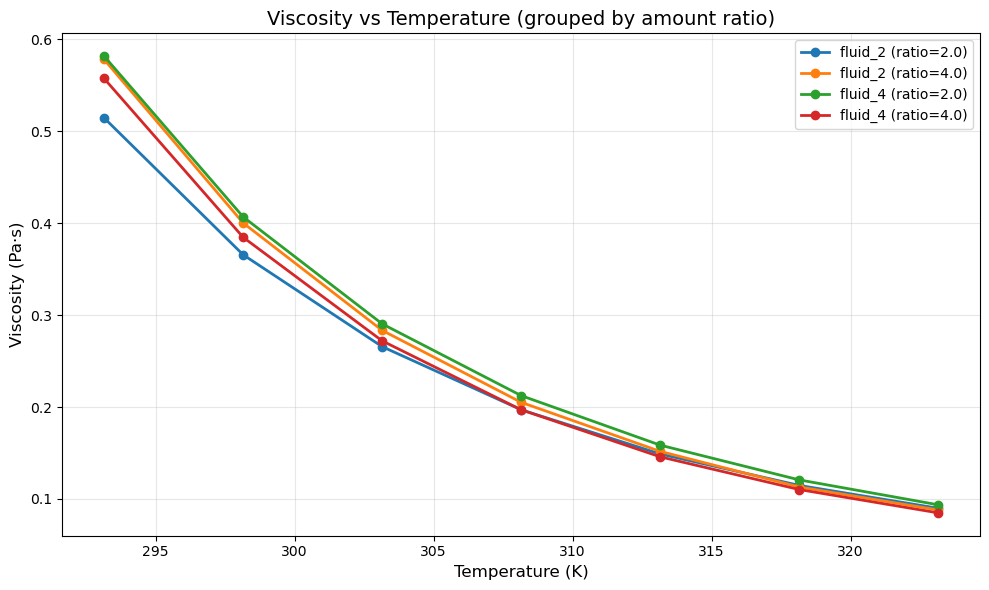

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Extract viscosity measurements over temperature for each fluid, grouped by amount ratio
plt.figure(figsize=(10, 6))

for fluid_idx, fluid in enumerate(gustav.get('fluid', [])):
    # Dictionary to group by amount ratio
    ratio_groups = {}
    
    sample = fluid.get('sample', {})
    measurements = sample.get('measurement', [])
    
    for meas in measurements:
        # Look for viscosity property
        prop_values = meas.get('propertyValue', [])
        param_values = meas.get('parameterValue', [])
        
        # Extract temperature and amount ratio
        temp = None
        amount_ratio = None
        for pv in param_values:
            param_name = pv.get('parameters', '').lower()
            if param_name == 'temperature':
                temp = pv.get('paramValue')
            elif 'amount ratio of solute to solvent' in param_name:
                amount_ratio = pv.get('paramValue')
        
        # Extract viscosity
        visc = None
        for pv in prop_values:
            if pv.get('properties', '').lower() == 'viscosity':
                visc = pv.get('propValue')
                if temp is not None and visc is not None and amount_ratio is not None:
                    if amount_ratio not in ratio_groups:
                        ratio_groups[amount_ratio] = {'temps': [], 'viscosities': []}
                    ratio_groups[amount_ratio]['temps'].append(temp)
                    ratio_groups[amount_ratio]['viscosities'].append(visc)
    
    # Plot each amount ratio group
    for amount_ratio, data in sorted(ratio_groups.items()):
        temps = data['temps']
        viscosities = data['viscosities']
        
        if temps and viscosities:
            # Sort by temperature
            sorted_data = sorted(zip(temps, viscosities))
            temps_sorted, visc_sorted = zip(*sorted_data)
            
            # Get fluid identifier for label
            fluid_id = fluid.get('fluidID', [f'Fluid {fluid_idx + 1}'])
            if isinstance(fluid_id, list):
                fluid_id = fluid_id[0] if fluid_id else f'Fluid {fluid_idx + 1}'
            
            label = f'{fluid_id} (ratio={amount_ratio})'
            plt.plot(temps_sorted, visc_sorted, 'o-', linewidth=2, markersize=6, label=label)
            print(f"Fluid {fluid_idx + 1}, Ratio {amount_ratio}: Found {len(temps)} viscosity measurements")

if plt.gca().has_data():
    plt.xlabel('Temperature (K)', fontsize=12)
    plt.ylabel('Viscosity (Pa·s)', fontsize=12)
    plt.title('Viscosity vs Temperature (grouped by amount ratio)', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No viscosity data found in gustav")
    print("\nAvailable properties in first measurement:")
    if gustav.get('fluid'):
        first_fluid = gustav['fluid'][0]
        sample = first_fluid.get('sample', {})
        measurements = sample.get('measurement', [])
        if measurements:
            first_meas = measurements[0]
            for pv in first_meas.get('propertyValue', []):
                print(f"  - {pv.get('properties', 'N/A')}")